# ASC5 Locus Coverage Plots

### imports

In [4]:
library(Gviz)
library(rtracklayer)
library(GenomicRanges)
library(SummarizedExperiment)
library(biomaRt)
library(TxDb.Hsapiens.UCSC.hg38.knownGene)
library(org.Hs.eg.db)
library(dplyr)

Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.4.2”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.4.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, saveRDS, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:



In [5]:
devtools::load_all('/home/workspace/MOCHA')
devtools::load_all('/home/workspace/ChAI')

ℹ Loading MOCHA
in method for 'callOpenTiles' with signature 'ATACFragments="ArchRProject"': no definition for class "ArchRProject"

ℹ Loading ChAI


### gene locus settings

need to change these based on which region of the gene you want look at (I check in IGviewer beforehand)

In [6]:
bw_asc5  <- "/home/workspace/Meta_Files/ASC5__All_Coverage.bw"
bw_asc2  <- "/home/workspace/Meta_Files/ASC2__All_Coverage.bw"

### create motif annotation files

In [7]:
STM <- readRDS('/home/workspace/Run_Metatype_12v5/MOCHA_SampleTileMatrix_Meta.rds')

In [8]:
library(chromVARmotifs)
data(human_pwms_v2)

In [9]:
# motif set should already be added to STM
motifsGRanges <- metadata(STM)$Motifs

In [10]:
gene_symbols <- c("FOXP2", "TNFRSF18", "CADPS2")

In [11]:
# Map gene symbols → Entrez IDs
entrez <- mapIds(
  org.Hs.eg.db,
  keys = gene_symbols,
  keytype = "SYMBOL",
  column = "ENTREZID",
  multiVals = "first")

txdb <- TxDb.Hsapiens.UCSC.hg38.knownGene

# Extract gene ranges
gr_genes <- genes(txdb)[entrez]
print(length(gr_genes))

gr_genes$gene_id     <- names(gr_genes)        # Entrez ID from TxDb
gr_genes$gene_symbol <- names(entrez)

promoters_gr <- promoters(
  gr_genes,
  upstream = 3000,
  downstream = 2000
)

target_regions <- c(gr_genes, promoters_gr)

target_regions

'select()' returned 1:1 mapping between keys and columns

  2162 genes were dropped because they have exons located on both strands
  of the same reference sequence or on more than one reference sequence,
  so cannot be represented by a single genomic range.
  Use 'single.strand.genes.only=FALSE' to get all the genes in a
  GRangesList object, or use suppressMessages() to suppress this message.



[1] 3


GRanges object with 6 ranges and 2 metadata columns:
        seqnames              ranges strand |     gene_id gene_symbol
           <Rle>           <IRanges>  <Rle> | <character> <character>
  93986     chr7 114086327-114693772      + |       93986       FOXP2
   8784     chr1     1203508-1206592      - |        8784    TNFRSF18
  93664     chr7 122318411-122886759      - |       93664      CADPS2
  93986     chr7 114083327-114088326      + |       93986       FOXP2
   8784     chr1     1204593-1209592      - |        8784    TNFRSF18
  93664     chr7 122884760-122889759      - |       93664      CADPS2
  -------
  seqinfo: 711 sequences (1 circular) from hg38 genome

In [12]:
hits <- queryHits(findOverlaps(rowRanges(STM), target_regions))

In [13]:
se_filtered <- STM[hits, ]
se_filtered

class: RangedSummarizedExperiment 
dim: 53 6 
metadata(8): summarizedData Genome ... InsertionBias Motifs
assays(2): ASC1_2 ASC5_2
rownames(53): chr1:1203500-1203999 chr1:1204000-1204499 ...
  chr7:122887500-122887999 chr7:122889000-122889499
rowData names(2): ASC1_2 ASC5_2
colnames(6): EXP-00776-P1_BMC05967-001 EXP-00776-P1_SP05965-01 ...
  EXP-00776-P1_SP06133-01 EXP-00776-P1_SP06134-01
colData names(5): Sample pool_id chip_id batch_id PassQC

In [14]:
se_filtered <- subsetMOCHAObject(se_filtered, subsetBy='celltype', groupList=c('ASC5_2'))
rowData(se_filtered) <- rowData(se_filtered)[, c('ASC5_2'), drop = FALSE]

In [15]:
motifsGRanges <- metadata(se_filtered)$Motifs

In [16]:
se_filtered

class: RangedSummarizedExperiment 
dim: 53 6 
metadata(8): summarizedData Genome ... InsertionBias Motifs
assays(1): ASC5_2
rownames(53): chr1:1203500-1203999 chr1:1204000-1204499 ...
  chr7:122887500-122887999 chr7:122889000-122889499
rowData names(1): ASC5_2
colnames(6): EXP-00776-P1_BMC05967-001 EXP-00776-P1_SP05965-01 ...
  EXP-00776-P1_SP06133-01 EXP-00776-P1_SP06134-01
colData names(5): Sample pool_id chip_id batch_id PassQC

In [17]:
exportPath <- exportMotifs(
  SampleTileObject=se_filtered,
  motifsGRanges,
  motifSetName = "Motifs",
  filterByOpenTiles = TRUE,
  outDir='/home/workspace/Meta_Files/Motif_Bed',
  verbose = TRUE
)


Attaching package: 'Biostrings'


The following object is masked from 'package:grid':

    pattern


The following object is masked from 'package:base':

    strsplit



Attaching package: 'BiocIO'


The following object is masked from 'package:rtracklayer':

    FileForFormat


Exporting: /home/workspace/Meta_Files/Motif_Bed/ASC5_2__Motifs__motifset.bigBed



In [18]:
bed <- import(unlist(exportPath))

In [19]:
bed

GRanges object with 2929 ranges and 2 metadata columns:
         seqnames              ranges strand |     score      strand
            <Rle>           <IRanges>  <Rle> | <numeric> <character>
     [1]     chr1     1203514-1203525      * |         8           -
     [2]     chr1     1203517-1203529      * |         7           -
     [3]     chr1     1203520-1203529      * |         9           -
     [4]     chr1     1203520-1203530      * |         8           -
     [5]     chr1     1203554-1203562      * |         7           +
     ...      ...                 ...    ... .       ...         ...
  [2925]     chr7 122889437-122889446      * |         8           -
  [2926]     chr7 122889438-122889455      * |         7           +
  [2927]     chr7 122889438-122889452      * |         7           +
  [2928]     chr7 122889454-122889475      * |         6           -
  [2929]     chr7 122889481-122889492      * |         9           +
  -------
  seqinfo: 2 sequences from an unspec

In [20]:
metadata(STM)$Motifs

GRangesList object of length 870:
$TFAP2B
GRanges object with 29998 ranges and 1 metadata column:
          seqnames              ranges strand |     score
             <Rle>           <IRanges>  <Rle> | <numeric>
      [1]    chr10 100010368-100010379      + |   9.20768
      [2]    chr10 100346808-100346819      + |   8.77550
      [3]    chr10 100346698-100346709      - |   8.64856
      [4]    chr10 100346808-100346819      - |   8.92994
      [5]    chr10 100561920-100561931      + |   9.06332
      ...      ...                 ...    ... .       ...
  [29994]     chrY   20798807-20798818      + |   8.81585
  [29995]     chrY   20798807-20798818      - |   9.39010
  [29996]     chrY   26409440-26409451      - |   8.98609
  [29997]     chrY     7274409-7274420      + |   9.12080
  [29998]     chrY     7274409-7274420      - |   8.39709
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

...
<869 more elements>

In [21]:
unique(bed$score)

[1]  8  7  9 10  1  5  4  6 11 16 12  3  2 13 14

In [22]:
# need to map motif names back to these regions
motif_grl <- motifsGRanges

motif_df <- bind_rows(
  lapply(names(motif_grl), function(tf) {
    df <- as.data.frame(motif_grl[[tf]])
    df$motif_name <- tf
    df
  })
)

motif_gr <- GRanges(
  seqnames = motif_df$seqnames,
  ranges = IRanges(start = motif_df$start, end = motif_df$end),
  strand = motif_df$strand,
  motif_name = motif_df$motif_name,
  score = motif_df$score
)

In [23]:
motif_filtered_gr <- subsetByOverlaps(motif_gr, bed)
motif_filtered_gr

GRanges object with 2930 ranges and 2 metadata columns:
         seqnames              ranges strand |  motif_name     score
            <Rle>           <IRanges>  <Rle> | <character> <numeric>
     [1]     chr1     1205387-1205398      - |      TFAP2B   8.33318
     [2]     chr1     1207231-1207242      + |      TFAP2B   8.75306
     [3]     chr1     1207784-1207795      + |      TFAP2B   8.73661
     [4]     chr7 114083575-114083586      + |      TFAP2B   8.71520
     [5]     chr7 114083575-114083586      - |      TFAP2B   9.15025
     ...      ...                 ...    ... .         ...       ...
  [2926]     chr7 122882780-122882787      - |        SOX6   8.10797
  [2927]     chr1     1207055-1207073      + |       TBX18   2.30162
  [2928]     chr7 122802548-122802566      - |       TBX18   1.59494
  [2929]     chr1     1207055-1207073      + |       TBX22   2.30162
  [2930]     chr7 122802548-122802566      - |       TBX22   1.59494
  -------
  seqinfo: 24 sequences from an unspe

now that we have all the motifs that are present surrounding our genes of interest, let's filter by motfis that are significantly upregulated (more open) in ASC5 based on our ChromVAR analysis

In [24]:
chromVAR_enriched <- read.csv('/home/workspace/Run_Metatype_threshold/anovaEnrichments.csv')

In [25]:
asc2 <- chromVAR_enriched %>%
  filter(cell_type %in% c('ASC2'))

In [26]:
dim(asc2)

[1] 870  15

In [27]:
celltype_enriched <- chromVAR_enriched %>%
  filter(cell_type %in% c('ASC5'))

In [28]:
dim(celltype_enriched)

[1] 870  15

In [29]:
# confirm median_delta_z > 0 and p_adj < 0.1
celltype_enriched <- celltype_enriched %>%
  filter(estimate > 0, p_adj < 0.1)
dim(celltype_enriched)

[1] 432  15

In [30]:
# filter by expression detection 
celltype_enriched <- celltype_enriched %>%
  filter(is_expressed)
dim(celltype_enriched)

[1] 203  15

In [31]:
motif_filtered_gr <- motif_filtered_gr[motif_filtered_gr$motif_name %in% unique(celltype_enriched$motif)]

In [32]:
motif_filtered_gr

GRanges object with 880 ranges and 2 metadata columns:
        seqnames              ranges strand |  motif_name     score
           <Rle>           <IRanges>  <Rle> | <character> <numeric>
    [1]     chr1     1209525-1209546      + |      ARID3A   9.56081
    [2]     chr1     1209526-1209547      + |      ARID3A   7.90648
    [3]     chr7 114084135-114084156      + |      ARID3A   7.40151
    [4]     chr7 114084295-114084316      + |      ARID3A   9.59650
    [5]     chr7 114084185-114084206      - |      ARID3A   8.43009
    ...      ...                 ...    ... .         ...       ...
  [876]     chr7 114085875-114085884      - |       FOXJ1   6.59237
  [877]     chr7 114087001-114087010      - |       FOXJ1   6.45150
  [878]     chr7 114088043-114088052      - |       FOXJ1   5.91856
  [879]     chr7 122885124-122885133      + |       FOXJ1   6.02888
  [880]     chr7 122889199-122889208      - |       FOXJ1   5.96243
  -------
  seqinfo: 24 sequences from an unspecified genome;

In [33]:
length(unique(motif_filtered_gr$motif_name))

[1] 173

ok so we have the motifs that are significantly and positively enriched for ASC 5 at our genes of interest, now we can plot

### import big wigs

*** this is the only thing that needs to be changed for each run ***

In [34]:
target_gene <- "CADPS2"

In [35]:
target_region <- target_regions[target_regions$gene_symbol == "CADPS2"]
target_region

GRanges object with 2 ranges and 2 metadata columns:
        seqnames              ranges strand |     gene_id gene_symbol
           <Rle>           <IRanges>  <Rle> | <character> <character>
  93664     chr7 122318411-122886759      - |       93664      CADPS2
  93664     chr7 122884760-122889759      - |       93664      CADPS2
  -------
  seqinfo: 711 sequences (1 circular) from hg38 genome

In [36]:
# start <- min(start(target_region)) - 4000
start <- min(start(target_region))
end <- max(end(target_region))
strand <- strand(target_region)[1]
chr <- as.character(seqnames(target_region)[1])

In [37]:
bw <- import(bw_asc5, as = "RleList")
asc5_rle <- bw[[chr]][start:end]  # base-level coverage

bw2 <- import(bw_asc2, as = "RleList")
asc2_rle <- bw2[[chr]][start:end]

In [38]:
asc5_vec <- as.numeric(asc5_rle)
asc2_vec <- as.numeric(asc2_rle)

In [39]:
delta_vec <- asc5_vec - asc2_vec

In [40]:
gr <- GRanges(
  seqnames = chr,
  ranges   = IRanges(start = start:end, width = 1),
  strand   = strand
)

# Sanity check: vector lengths must match region size
stopifnot(
  length(gr) == length(asc5_vec),
  length(asc2_vec) == length(asc5_vec),
  length(delta_vec) == length(asc5_vec)
)

# Attach scores
asc5_gr  <- gr; asc5_gr$score  <- asc5_vec
asc2_gr  <- gr; asc2_gr$score  <- asc2_vec
delta_gr <- gr; delta_gr$score <- delta_vec


### plot motif track

In [41]:
motif_filtered_gr

GRanges object with 880 ranges and 2 metadata columns:
        seqnames              ranges strand |  motif_name     score
           <Rle>           <IRanges>  <Rle> | <character> <numeric>
    [1]     chr1     1209525-1209546      + |      ARID3A   9.56081
    [2]     chr1     1209526-1209547      + |      ARID3A   7.90648
    [3]     chr7 114084135-114084156      + |      ARID3A   7.40151
    [4]     chr7 114084295-114084316      + |      ARID3A   9.59650
    [5]     chr7 114084185-114084206      - |      ARID3A   8.43009
    ...      ...                 ...    ... .         ...       ...
  [876]     chr7 114085875-114085884      - |       FOXJ1   6.59237
  [877]     chr7 114087001-114087010      - |       FOXJ1   6.45150
  [878]     chr7 114088043-114088052      - |       FOXJ1   5.91856
  [879]     chr7 122885124-122885133      + |       FOXJ1   6.02888
  [880]     chr7 122889199-122889208      - |       FOXJ1   5.96243
  -------
  seqinfo: 24 sequences from an unspecified genome;

In [42]:
select_motifs <- subsetByOverlaps(
  motif_filtered_gr,
  target_region
)

In [43]:
select_motifs

GRanges object with 118 ranges and 2 metadata columns:
        seqnames              ranges strand |  motif_name     score
           <Rle>           <IRanges>  <Rle> | <character> <numeric>
    [1]     chr7 122518516-122518537      - |      ARID3A   6.60867
    [2]     chr7 122544931-122544952      - |      ARID3A   7.23377
    [3]     chr7 122802792-122802813      - |      ARID3A   7.04460
    [4]     chr7 122803010-122803031      - |      ARID3A   7.32068
    [5]     chr7 122803026-122803047      - |      ARID3A   7.54158
    ...      ...                 ...    ... .         ...       ...
  [114]     chr7 122886519-122886535      - |        PURA   9.06182
  [115]     chr7 122886546-122886562      - |        PURA   9.52979
  [116]     chr7 122886552-122886568      - |        PURA   9.05577
  [117]     chr7 122887873-122887890      - |       KLF10   7.86400
  [118]     chr7 122889199-122889208      - |       FOXJ1   5.96243
  -------
  seqinfo: 24 sequences from an unspecified genome;

also need to highlight differentially accessible region and filter to motifs to only in that region

In [44]:
dat_table <- read.csv('/home/workspace/Run_Metatype_12v5/DAT_table_5v12_annotated.csv')

doesn't really matter if we filter dat table since we hand selected our target genes/promoter regions based on this table anyway

In [45]:
# also read in 1 vs all comparison dats
dat_table2 <- read.csv('/home/workspace/Run_Metatype_threshold/DAT_table_gene_annotated.csv')

In [46]:
length(unique(dat_table$Tiles))

[1] 66614

In [47]:
length(unique(dat_table2$Tiles))

[1] 80329

In [48]:
dats <- unique(c(dat_table$Tiles, dat_table2$Tiles))

In [49]:
dats_gr <- StringsToGRanges(dats)

In [50]:
select_dats <- subsetByOverlaps(
  dats_gr,
  target_region
)

In [51]:
select_dats

GRanges object with 13 ranges and 0 metadata columns:
       seqnames              ranges strand
          <Rle>           <IRanges>  <Rle>
   [1]     chr7 122885500-122885999      *
   [2]     chr7 122886000-122886499      *
   [3]     chr7 122886500-122886999      *
   [4]     chr7 122887000-122887499      *
   [5]     chr7 122597000-122597499      *
   ...      ...                 ...    ...
   [9]     chr7 122889000-122889499      *
  [10]     chr7 122544500-122544999      *
  [11]     chr7 122803500-122803999      *
  [12]     chr7 122885000-122885499      *
  [13]     chr7 122887500-122887999      *
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [52]:
str_select_dats <- GRangesToString(select_dats)

In [53]:
dat_table2 %>% filter(Tiles %in% str_select_dats)

X,gene_id,promoter_gene_id,promoter_symbol,gene_symbol,annotation,Estimate,Std_Error,z_value,p_value,FDR,Tiles,CellType
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
chr7:122544500-122544999,93664,NA,,CADPS2,intron,1.844032,0.3783284,4.874157,1.092741e-06,2.631108e-04,chr7:122544500-122544999,ASC5
chr7:122597000-122597499,93664,NA,,CADPS2,intron,1.863596,0.6086177,3.062014,2.198529e-03,3.957315e-02,chr7:122597000-122597499,ASC5
chr7:122802500-122802999,93664,NA,,CADPS2,intron,2.051186,0.7683970,2.669435,7.597888e-03,8.184849e-02,chr7:122802500-122802999,ASC5
chr7:122803000-122803499,93664,NA,,CADPS2,intron,1.735667,0.4811803,3.607104,3.096341e-04,1.199428e-02,chr7:122803000-122803499,ASC5
chr7:122803500-122803999,93664,NA,,CADPS2,intron,1.647266,0.4226366,3.897594,9.715313e-05,5.710399e-03,chr7:122803500-122803999,ASC5
chr7:122885000-122885499,93664,NA,,CADPS2,intron,1.293823,0.2844360,4.548731,5.397034e-06,8.202835e-04,chr7:122885000-122885499,ASC5
chr7:122885500-122885999,93664,NA,,CADPS2,intron,1.652408,0.5088557,3.247301,1.165050e-03,2.711543e-02,chr7:122885500-122885999,ASC5
chr7:122886500-122886999,93664,93664,CADPS2,CADPS2,exon,2.514886,0.6253376,4.021645,5.779320e-05,4.052347e-03,chr7:122886500-122886999,ASC5
chr7:122887500-122887999,NA,93664,CADPS2,,promoter,1.807508,0.4763353,3.794612,1.478744e-04,7.453054e-03,chr7:122887500-122887999,ASC5


subset motifs again 

In [54]:
select_motifs <- subsetByOverlaps(
  select_motifs,
  select_dats
)

In [55]:
select_dats <- reduce(select_dats)
select_dats

GRanges object with 6 ranges and 0 metadata columns:
      seqnames              ranges strand
         <Rle>           <IRanges>  <Rle>
  [1]     chr7 122544500-122544999      *
  [2]     chr7 122597000-122597499      *
  [3]     chr7 122802500-122803999      *
  [4]     chr7 122882500-122882999      *
  [5]     chr7 122885000-122887999      *
  [6]     chr7 122889000-122889499      *
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

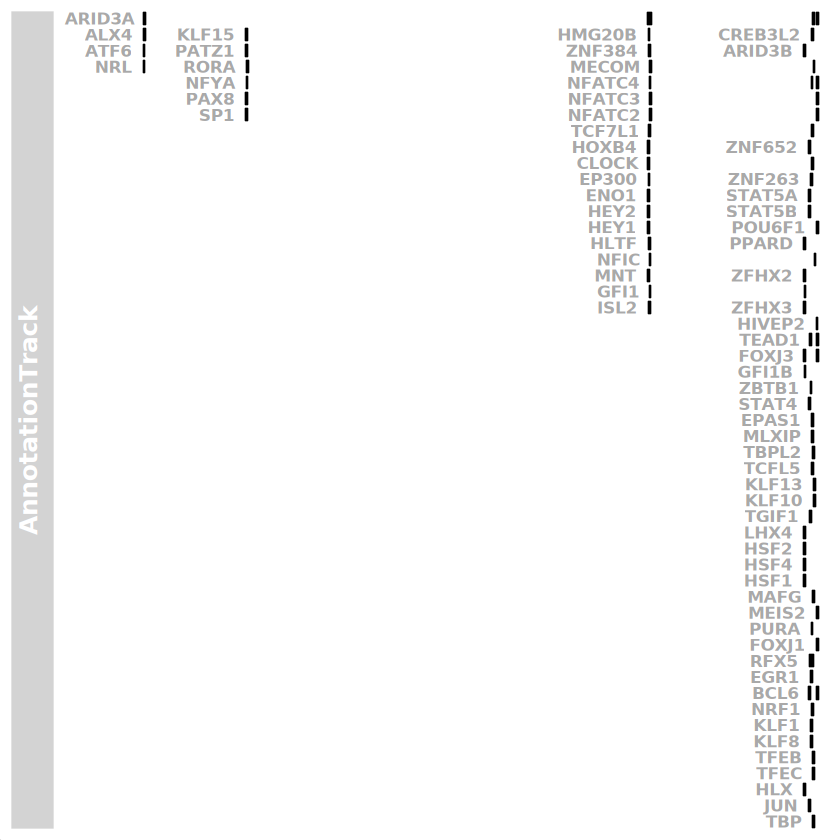

In [56]:
motif_track <- AnnotationTrack(
    select_motifs,
    shape='box',
    group = mcols(select_motifs)$motif_name,
    # featureAnnotation='group',
    groupAnnotation='group',
    fontcolor.group = "darkgrey",
    just.group = 'left',
    cex.group = 0.8,
    col.line = NA,
    fill = 'black',
    col = 'black',
    extend.left = 5
)

plotTracks(motif_track)

In [62]:
# let's try just plotting motifs from the top 20 (motifs highlighted in dotplot)
# frick I also forgot to filter by motifs that are detected in RNA - okay went back and fixed that

top20 <- celltype_enriched %>%
  filter(p_adj < 0.1) %>%
  filter(estimate > 0) %>%
  group_by(cell_type) %>%
  slice_max(order_by = estimate, n = 50, with_ties = FALSE) %>%
  ungroup()

top20

X.1,X,contrast,estimate,SE,df,t.ratio,p.value,motif,p_adj,mlogadjpval,cell_type,statistic,is_top20,is_expressed
<int>,<int>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<lgl>,<lgl>
695,695,ASC5 effect,23.983780,6.5602427,19,3.655929,4.200724e-03,JUNB,8.000503e-03,2.096883,ASC5,50.29117,TRUE,TRUE
525,525,ASC5 effect,23.806537,6.5801501,19,3.617932,4.580341e-03,FOSL2,8.674133e-03,2.061774,ASC5,49.08370,TRUE,TRUE
715,715,ASC5 effect,23.799523,6.3762501,19,3.732527,3.163764e-03,JUN,6.202061e-03,2.207464,ASC5,52.53659,TRUE,TRUE
710,710,ASC5 effect,23.219104,6.7228880,19,3.453740,4.541409e-03,FOSL1,8.615406e-03,2.064724,ASC5,47.94105,TRUE,TRUE
685,685,ASC5 effect,22.500659,6.0617404,19,3.711914,3.697556e-03,FOS,7.132757e-03,2.146743,ASC5,48.30312,TRUE,TRUE
3255,3255,ASC5 effect,22.193789,6.1656774,19,3.599570,3.961099e-03,SMARCC1,7.580634e-03,2.120294,ASC5,47.05737,TRUE,TRUE
620,620,ASC5 effect,21.978058,6.0616245,19,3.625770,4.499345e-03,JUND,8.550525e-03,2.068007,ASC5,45.45078,TRUE,TRUE
625,625,ASC5 effect,20.866585,5.7120417,19,3.653087,4.228004e-03,JDP2,8.047870e-03,2.094319,ASC5,43.70129,TRUE,TRUE
650,650,ASC5 effect,19.850185,6.1713402,19,3.216511,7.571361e-03,BACH1,1.362657e-02,1.865613,ASC5,37.03277,TRUE,TRUE


In [63]:
select_motifs_20 <- select_motifs[select_motifs$motif_name %in% top20$motif, ]
length(unique(select_motifs_20$motif_name))

[1] 9

In [64]:
length(unique(select_motifs$motif_name))

[1] 70

In [65]:
select_motifs_20

GRanges object with 9 ranges and 2 metadata columns:
      seqnames              ranges strand |  motif_name     score
         <Rle>           <IRanges>  <Rle> | <character> <numeric>
  [1]     chr7 122887428-122887437      - |        TFEC   8.22939
  [2]     chr7 122887428-122887437      - |        TFEB   8.20090
  [3]     chr7 122802727-122802736      - |        HEY2   9.66417
  [4]     chr7 122802727-122802736      - |        HEY1   8.72153
  [5]     chr7 122886744-122886751      - |       MLXIP   8.95494
  [6]     chr7 122885151-122885161      - |         JUN   7.96362
  [7]     chr7 122597135-122597147      - |       PATZ1   9.86995
  [8]     chr7 122887873-122887890      - |       KLF13   7.86400
  [9]     chr7 122887873-122887890      - |       KLF10   7.86400
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

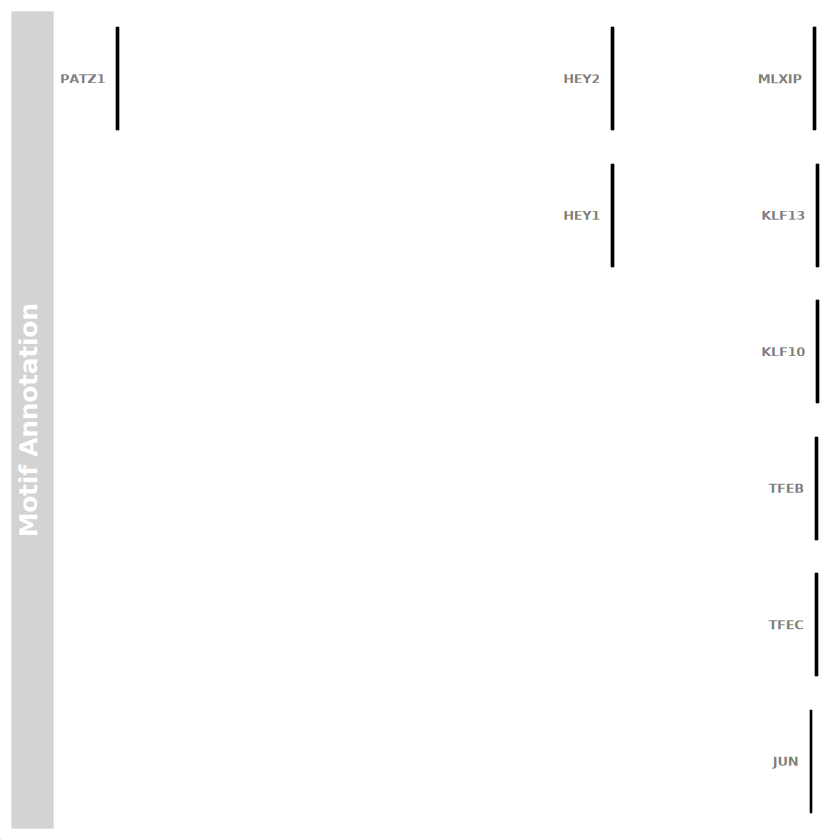

In [66]:
motif_track <- AnnotationTrack(
    select_motifs_20,
    shape='box',
    name='Motif Annotation',
    feature = mcols(select_motifs_20)$motif_name,
    # featureAnnotation='feature',
    groupAnnotation='feature',
    fontcolor.feature = "darkgrey",
    just.feature = 'left',
    cex.feature = 0.8,
    col.line = NA,
    fill = 'black',
    col = 'black',
    extend.left = 5,
    stacking='squish'
)

plotTracks(motif_track)

## Coverage Tracks

In [67]:
ylim_all <- range(c(asc5_vec, asc2_vec, asc5_vec - asc2_vec), na.rm=TRUE)

asc5_track <- DataTrack(
    range = asc5_gr,
    type = "histogram",
    name = "ASC5",
    col.histogram = "#E8A29E",
    fill = "#E8A29E",
    ylim = ylim_all
)

asc2_track <- DataTrack(
    range = asc2_gr,
    type = "histogram",
    name = "ASC2",
    col.histogram = "#4B6A94",
    fill = "#4B6A94",
    ylim = ylim_all
)

delta_track <- DataTrack(
    range = delta_gr,
    type = "histogram",
    name = "Delta",
    col.histogram = "#696969",
    fill = "#696969",
    ylim = ylim_all
)

## Gene Track

In [68]:
gene_ids <- unique(target_region$gene_id) 
gene_symbol <- unique(target_region$gene_symbol) 

gene_track <- GeneRegionTrack(
    TxDb.Hsapiens.UCSC.hg38.knownGene,
    chromosome = chr,
    start = start,
    end = end,
    #  = as.character(strand),
    name = "",
    # symbol = gene_symbol,
    transcriptAnnotation = "symbol",
    collapseTranscripts = FALSE
)

# gene_track@range$symbol <- gene_symbol
# gene_track@range$transcript <- gene_symbol
# gene_track@range$symbol <- gene_symbols[as.character(gene_track@range$gene)]

# Customize appearance
displayPars(gene_track)$fill <- "darkgrey"
displayPars(gene_track)$col <- "darkgrey"
displayPars(gene_track)$lty <- 1
displayPars(gene_track)$arrowhead.width <- 0.1
displayPars(gene_track)$cex.group <- 0.8
displayPars(gene_track)$fontcolor.group <- "darkgrey"
displayPars(gene_track)$just.group <- "left"
displayPars(gene_track)$stacking <- "squish"

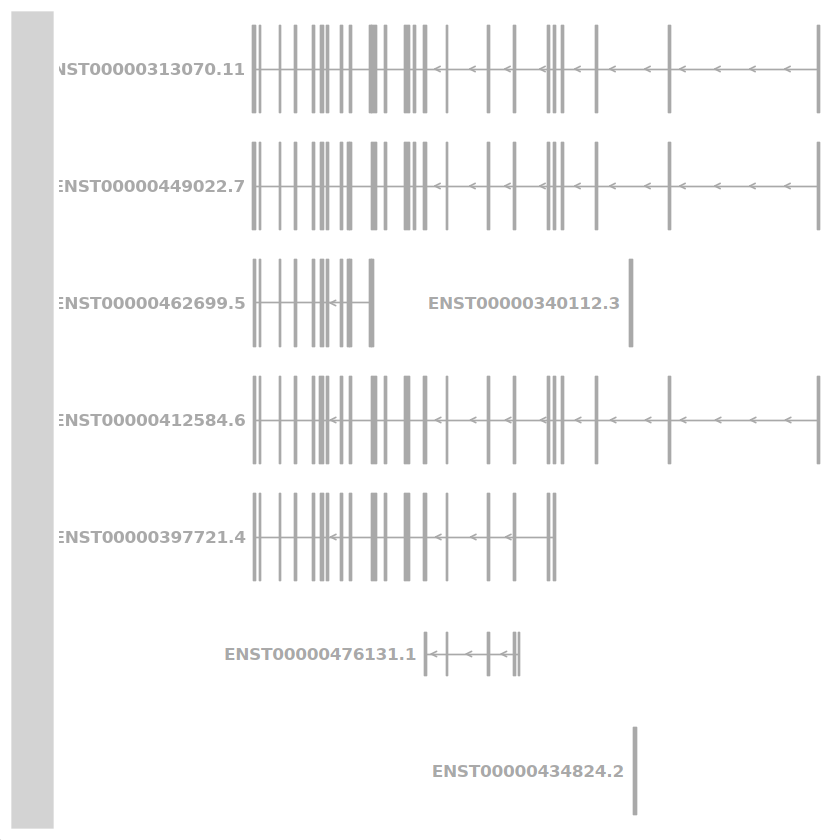

In [69]:
plotTracks(gene_track)

## Format Tracks

In [70]:
axis_track <- GenomeAxisTrack(
    labelPos = "below",
    littleTicks = TRUE,
    cex = 0.5,
    col="black",
    fontcolor="black",
    showID=FALSE
)

In [71]:
axis_track <- GenomeAxisTrack(
    # name = "Chromosome 7",
    labelPos = "below",
    col="black",
    fontcolor="black",
    showID=FALSE
)

In [72]:
spacer_track <- AnnotationTrack(
  start = start,
  end   = end,
  chromosome = chr,
  name = "",            # no title
  showTitle = FALSE,    # hide title
  showFeature = FALSE,  # hide any features
  showId = FALSE,
  fill = 'white',
  col = 'white',
)

## Plot Tracks

### FOXP2

In [137]:
displayPars(gene_track)$just.group <- "left"
displayPars(motif_track)$just.group <- "left"

In [138]:
gene_track@range <- subset(gene_track@range, gene %in% c(target_region$gene_id))
gene_track@range <- subset(gene_track@range, symbol %in% c('ENST00000412402.5'))
gene_track@range$symbol <- 'FOXP2'

In [150]:
ht <- HighlightTrack(
  track = c(asc5_track, asc2_track, delta_track, motif_track),
  range = select_dats[1],
  col = NA,
  fill = "#e8e8e8"
)

In [140]:
axis_track <- GenomeAxisTrack(
    labelPos = "below",
    littleTicks = FALSE,
    cex = 0.5,
    col="black",
    fontcolor="black",
    showID=FALSE
)

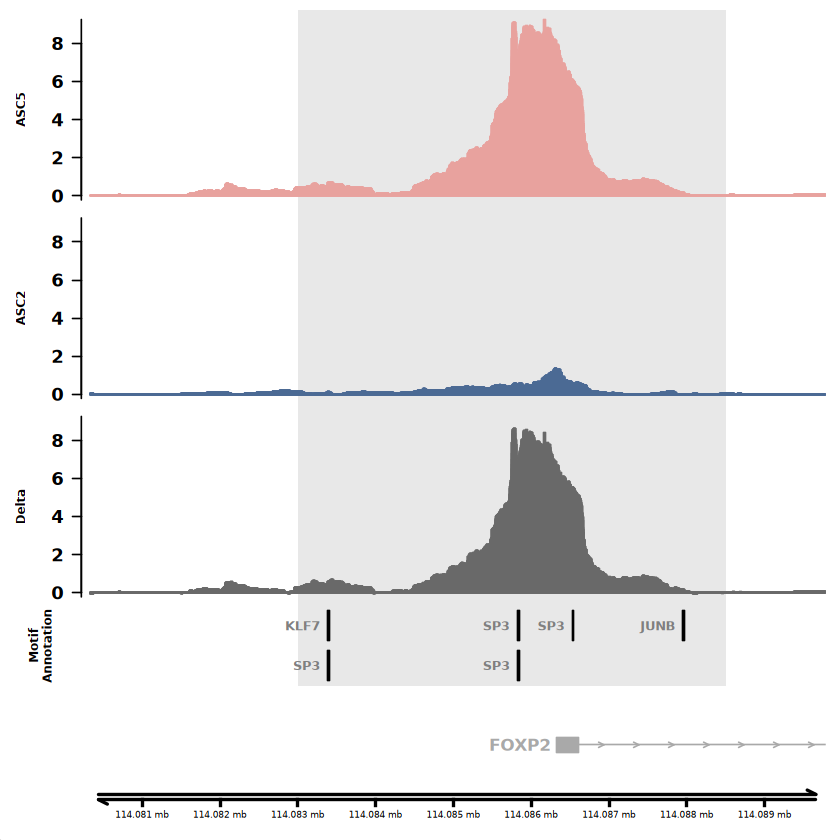

In [156]:
plotTracks(
    list(ht,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start + 1000, # 114080055 + 2000,
    to = end - 604000, # 114093520 - 3000,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    background.title = "white",
    col.axis = 'black',
    background.title = "white"
)

In [157]:
pdf("coverage_plots_final/FOXP2_2.pdf", width = 5, height = 6)

plotTracks(
    list(ht,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start + 1000, # 114080055 + 2000,
    to = end - 604000, # 114093520 - 3000,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    background.title = "white",
    col.axis = 'black',
    background.title = "white"
)

dev.off()

agg_record_534543625 
                   2

### TNFRSF18

In [192]:
gene_track@range <- subset(gene_track@range, gene %in% c(target_region$gene_id))
gene_track@range <- subset(gene_track@range, symbol %in% c('ENST00000379268.7'))
gene_track@range$symbol <- 'TNFRSF18'

In [193]:
displayPars(gene_track)$just.group <- "right"
displayPars(motif_track)$just.group <- "right"

In [194]:
ht <- HighlightTrack(
  track = c(asc5_track, asc2_track, delta_track, motif_track),
  range = select_dats,
  col = NA,
  fill = "#e8e8e8"
)

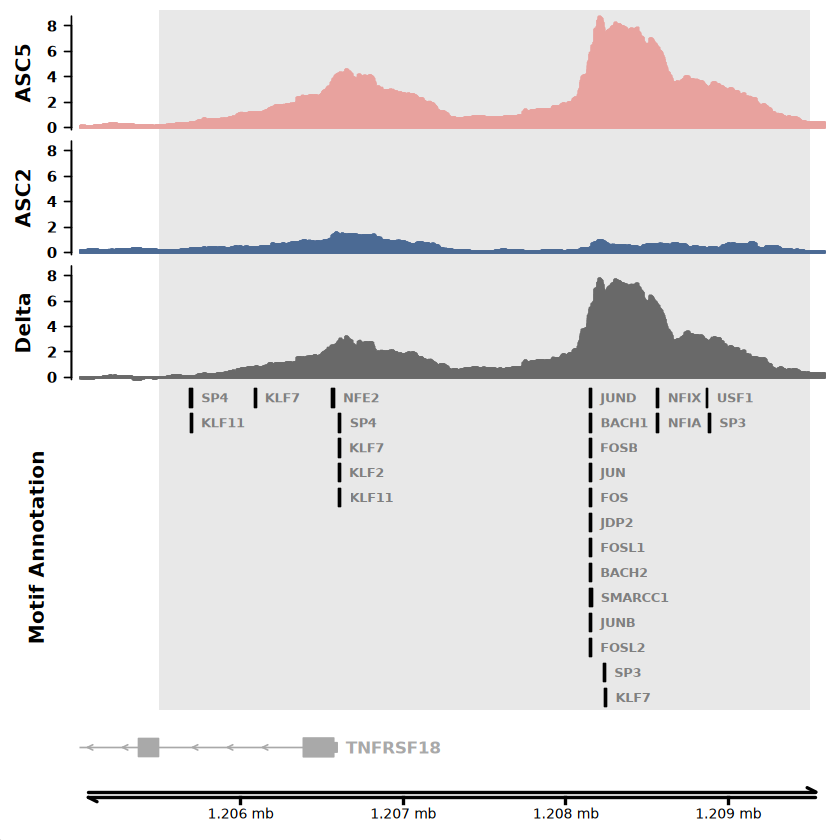

In [197]:
plotTracks(
    list(
        ht,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start + 1500,
    to = end,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    col.axis = 'black',
    background.title = "white"
    # main = "Chromosome 7"
)

In [198]:
pdf("coverage_plots_final/TNFRSF18_2.pdf", width = 5, height = 6)
plotTracks(
    list(
        ht,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start + 1500,
    to = end,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    col.axis = 'black',
    background.title = "white"
    # main = "Chromosome 7"
)

dev.off()

agg_record_2025444736 
                    2

### CADPS2

In [73]:
displayPars(gene_track)$just.group <- "right"
displayPars(motif_track)$just.group <- "right"

In [74]:
gene_track@range <- subset(gene_track@range, gene %in% c(target_region$gene_id))
gene_track@range <- subset(gene_track@range, symbol %in% c('ENST00000313070.11'))

In [75]:
gene_track@range$symbol <- 'CADPS2'

In [76]:
select_dats

GRanges object with 6 ranges and 0 metadata columns:
      seqnames              ranges strand
         <Rle>           <IRanges>  <Rle>
  [1]     chr7 122544500-122544999      *
  [2]     chr7 122597000-122597499      *
  [3]     chr7 122802500-122803999      *
  [4]     chr7 122882500-122882999      *
  [5]     chr7 122885000-122887999      *
  [6]     chr7 122889000-122889499      *
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [77]:
select_dats2 <- select_dats[5]

In [78]:
select_dats2

GRanges object with 1 range and 0 metadata columns:
      seqnames              ranges strand
         <Rle>           <IRanges>  <Rle>
  [1]     chr7 122885000-122887999      *
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [79]:
select_motifs2 <- subsetByOverlaps(
  select_motifs,
  select_dats2
)

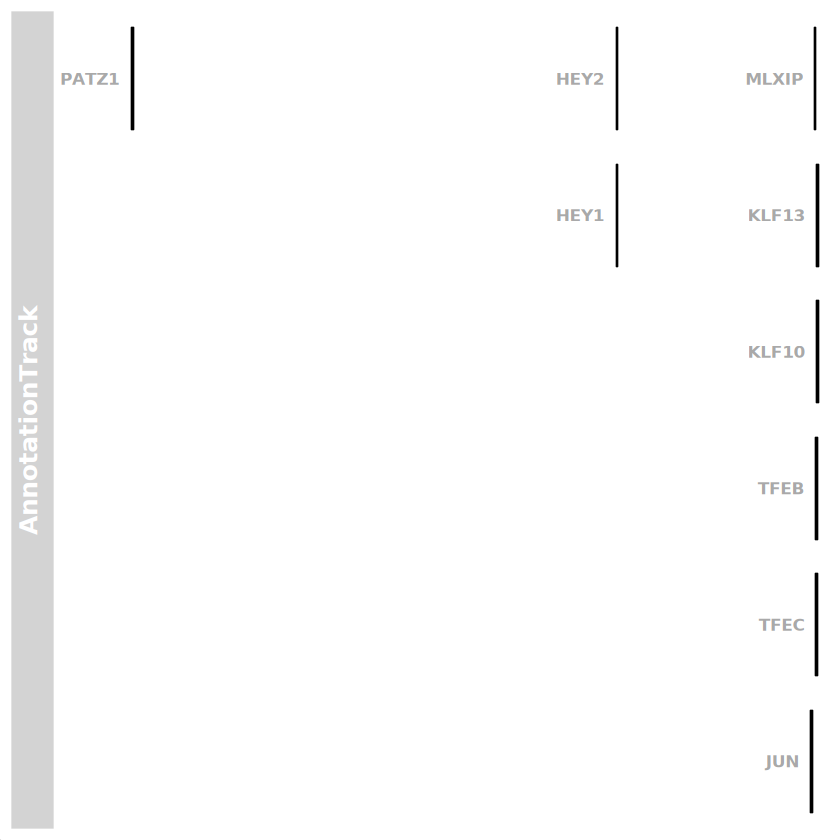

In [84]:
motif_track <- AnnotationTrack(
    select_motifs_20,
    shape='box',
    group = mcols(select_motifs_20)$motif_name,
    # featureAnnotation='group',
    groupAnnotation='group',
    fontcolor.group = "darkgrey",
    just.group = 'left',
    cex.group = 0.8,
    col.line = NA,
    fill = 'black',
    col = 'black',
    extend.left = 5
)

plotTracks(motif_track)

In [85]:
ht <- HighlightTrack(
  track = c(asc5_track, asc2_track, delta_track, motif_track),
  range = select_dats,
  col = NA,
  fill = "#e8e8e8"
)

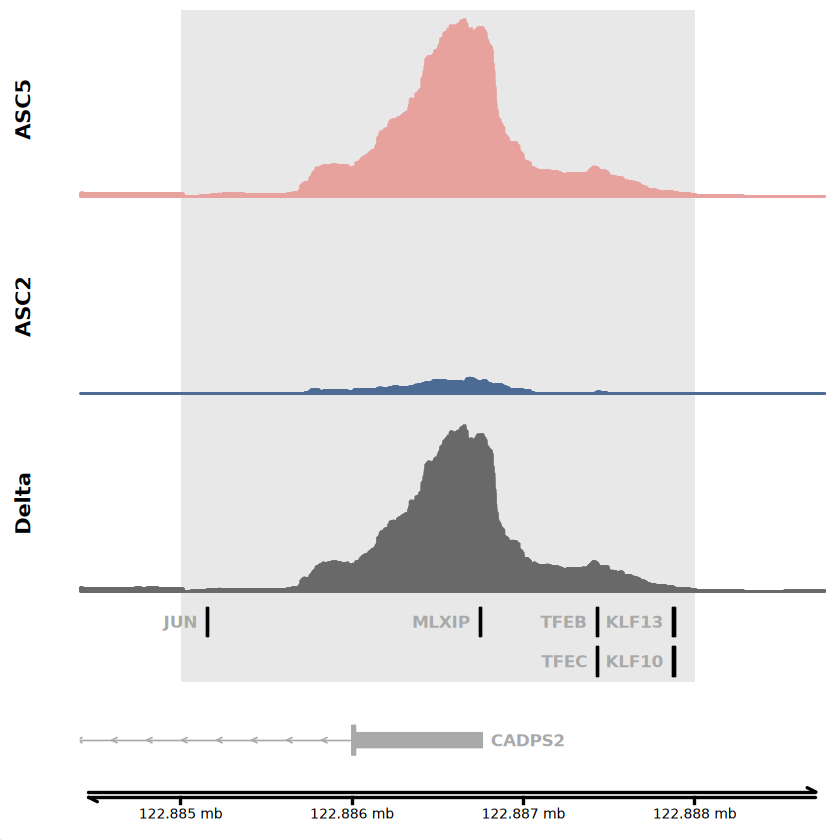

In [86]:
plotTracks(
    list(ht,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start + 566000,
    to = end - 1000,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    background.title = "white"
)

In [87]:
pdf("coverage_plots_final/CADPS2_3.pdf", width = 5, height = 6)

plotTracks(
    list(ht,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start + 566000,
    to = end - 1000,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    background.title = "white"
)

dev.off()

agg_record_674650661 
                   2

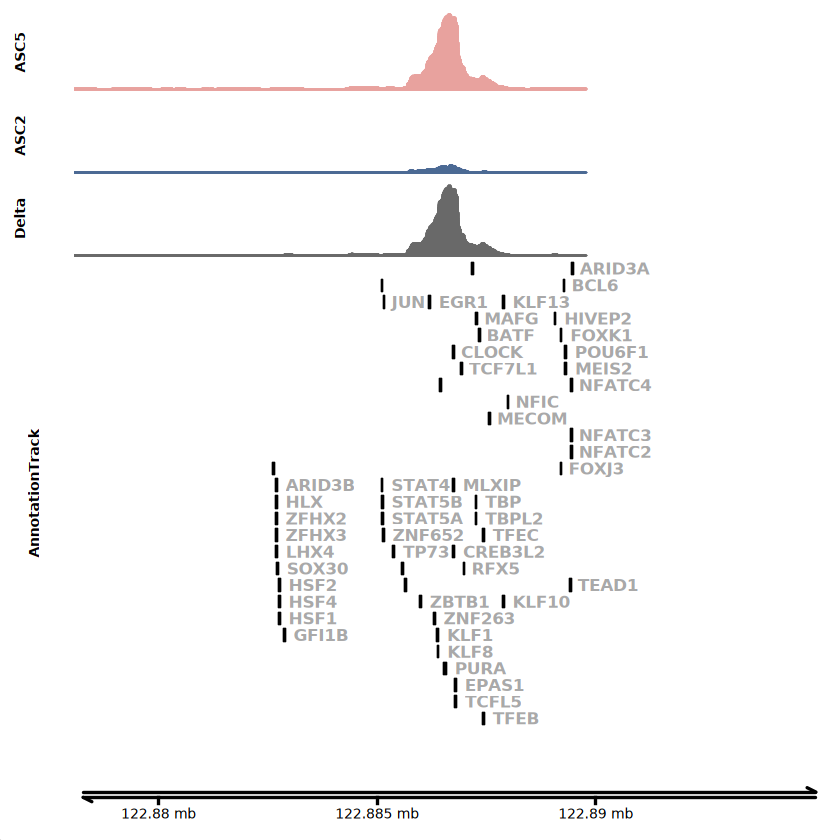

In [74]:
plotTracks(
    list(
        asc5_track,
        asc2_track,
        delta_track,
        motif_track,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = 122877069 + 1000,
    to = 122895237,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    background.title = "white"
)

In [139]:
allEnrichments <- read.csv('/home/workspace/Run_Metatype_threshold/Meta_EnrichedMotifs_ChromVAR_ANOVA.csv')

In [140]:
allEnrichments %>%
    filter(motif %in% c('EGR1', 'BATF'))

X,contrast,estimate,SE,df,t.ratio,p.value,motif,p_adj,mlogadjpval
<int>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
641,ASC1 effect,-3.2847865,3.4961607,19,-0.939541,4.490562e-01,BATF,5.433643e-01,0.26490893
642,ASC2 effect,-9.9892066,3.2114287,19,-3.110518,2.879241e-02,BATF,4.649108e-02,1.33263034
643,ASC3 effect,0.8277392,3.2114287,19,0.257748,7.993724e-01,BATF,8.622044e-01,0.06438979
644,ASC4 effect,6.1781823,3.2114287,19,1.923811,1.158183e-01,BATF,1.637341e-01,0.78586096
645,ASC5 effect,6.2680715,3.2114287,19,1.951802,1.158183e-01,BATF,1.637341e-01,0.78586096
971,ASC1 effect,-4.8025129,0.4026115,19,-11.928405,4.777091e-10,EGR1,6.996749e-09,8.15510372
972,ASC2 effect,-6.6120023,0.3698223,19,-17.878864,1.209528e-12,EGR1,4.963627e-11,10.30420083
973,ASC3 effect,4.4211281,0.3698223,19,11.954737,4.777091e-10,EGR1,6.996749e-09,8.15510372
974,ASC4 effect,3.5480620,0.3698223,19,9.593965,1.277269e-08,EGR1,1.060328e-07,6.97455982
